# Predicting Edinburgh Commercial Unit Survival (1986–2015) Using Logistic Regression

## Imports

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from functools import reduce
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import (accuracy_score, classification_report, roc_curve, auc)
from scipy.stats import chi2_contingency
import warnings
from matplotlib.lines import Line2D
from scipy.stats import chi2
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import matplotlib.image as mpimg


# Global plotting: whitegrid theme, colourblind-friendly palette, legible font
sns.set_theme(style="whitegrid")
sns.set_palette("colorblind")
plt.rcParams.update({'font.size': 14, 'figure.dpi': 200})

<span style="display: none">\newpage</span>

# Data

## Loading the Survey Data

We load each file and set `OBJECTID` as the index so we can align records across survey years when constructing the master dataset.

In [21]:
df_86 = pd.read_csv('datasets/Shop_Survey_1986.csv').set_index('OBJECTID')
df_96 = pd.read_csv('datasets/Shop_Survey_1996.csv').set_index('OBJECTID')
df_04 = pd.read_csv('datasets/Shop_Survey_2004.csv').set_index('OBJECTID')
df_10 = pd.read_csv('datasets/Shop_Survey_2010.csv').set_index('OBJECTID')
df_15 = pd.read_csv('datasets/Shop_Survey_2015.csv').set_index('OBJECTID')

df_86.head().T

OBJECTID,1,2,3,4,5
X,326794.4614,327067.4706,326939.8169,328372.6636,325432.0
Y,673934.3841,674402.0065,674274.0781,674066.0148,674403.0
DESCRIP86,restaurant,hairdresser,vacant,surgery,restaurant
BUSINESS86,,,,,
USECLASS86,Class 3,Class 1,Vacant,Class 2,Class 3
USECLASS96,Class 9,Class 1,Demolished,Class 4,Class 3
USECLASS04,Class 3,,,Class 4,
USECLASS10,Class 3,,,Class 4,
ADDRESS,9 ABBEY STRAND,,,4 ABERCORN ROAD,
POSTCODE,EH8 8DU,,,EH8 7DE,


The 2015 survey uses `CVR15_POST` instead of `POSTCODE`. We rename this column to harmonise naming conventions before merging, ensuring the postcode field can be coalesced consistently across all five survey years.

In [22]:
df_15 = df_15.rename(columns={'CVR15_POST': 'POSTCODE'})
df_15['POSTCODE'].head()

OBJECTID
1    EH8 8HH
2           
3    EH8 8DU
4    EH8 8EA
5    EH8 7DE
Name: POSTCODE, dtype: str

## Handling Whitespace-Only Values

Some raw CSV cells contain only whitespace (e.g. `"  "`), which Pandas reads as non-null strings. These must be converted to `NaN` so that our subsequent `combine_first` merge correctly prioritises genuine non-empty values from other survey years when filling missing data.

In [23]:
df_86, df_96, df_04, df_10, df_15 = [
    df.replace(r'^\s*$', np.nan, regex=True)
    for df in [df_86, df_96, df_04, df_10, df_15]
]

df_86.head().T

OBJECTID,1,2,3,4,5
X,326794.4614,327067.4706,326939.8169,328372.6636,325432.0
Y,673934.3841,674402.0065,674274.0781,674066.0148,674403.0
DESCRIP86,restaurant,hairdresser,vacant,surgery,restaurant
BUSINESS86,NaN,NaN,NaN,NaN,NaN
USECLASS86,Class 3,Class 1,Vacant,Class 2,Class 3
USECLASS96,Class 9,Class 1,Demolished,Class 4,Class 3
USECLASS04,Class 3,NaN,NaN,Class 4,NaN
USECLASS10,Class 3,NaN,NaN,Class 4,NaN
ADDRESS,9 ABBEY STRAND,NaN,NaN,4 ABERCORN ROAD,NaN
POSTCODE,EH8 8DU,NaN,NaN,EH8 7DE,NaN


## Merging Into a Master Dataset

We merge the five survey DataFrames into a single master dataset with one row per commercial unit. Shared columns (`X`, `Y`, `POSTCODE`, `ADDRESS`) are coalesced using `combine_first`, cascading through survey years to take the first non-null value and maximise data retention. Year-specific use-class and business name columns are joined to produce a wide-format table capturing each unit's trajectory across all survey waves.

In [24]:
survey_dfs = [df_86, df_96, df_04, df_10, df_15]
shared_cols = ['X', 'Y', 'POSTCODE', 'ADDRESS']

df_master = pd.DataFrame(index=reduce(pd.Index.union,
                                       [df.index for df in survey_dfs]))

df_master[shared_cols] = reduce(
    lambda a, b: a.combine_first(b),
    [df[shared_cols] for df in survey_dfs]
)

df_master = df_master.assign(
    Class_1986=reduce(lambda a, b: a.combine_first(b),
                      [df['USECLASS86'] for df in [df_86, df_96, df_04, df_10]]),
    Class_1996=reduce(lambda a, b: a.combine_first(b),
                      [df['USECLASS96'] for df in [df_96, df_86, df_04, df_10]]),
    Class_2004=reduce(lambda a, b: a.combine_first(b),
                      [df['USECLASS04'] for df in [df_04, df_86, df_96, df_10]]),
    Class_2010=reduce(lambda a, b: a.combine_first(b),
                      [df['USECLASS10'] for df in [df_10, df_86, df_96, df_04]]),
    Class_2015=df_15['USECLASS15'],
)

In [25]:
df_master = df_master.join(
    pd.concat([
        df_86['BUSINESS86'].rename('Business_1986'),
        df_96['BUSINESS96'].rename('Business_1996'),
        df_04['BUSINESS04'].rename('Business_2004'),
        df_10['BUSINESS10'].rename('Business_2010'),
        df_15['BUSINESS15'].rename('Business_2015'),
    ], axis=1)
)

df_master = df_master.rename_axis('OBJECTID').reset_index()

In [26]:
print(f"Master dataset shape: {df_master.shape}")
display(df_master.head().T)

Master dataset shape: (7668, 15)


,0,1,2,3,4
OBJECTID,1,2,3,4,5
X,326794.4614,327067.4706,326939.8169,328372.6636,325432.0
Y,673934.3841,674402.0065,674274.0781,674066.0148,674403.0
POSTCODE,EH8 8DU,EH8 8DU,EH8 8EA,EH8 7DE,EH3 6LB
ADDRESS,9 ABBEY STRAND,9(GF) ABBEY STRAND,55 ABBEYHILL,4 ABERCORN ROAD,8B ABERCROMBY PLACE
Class_1986,Class 3,Class 1,Vacant,Class 2,Class 3
Class_1996,Class 9,Class 1,Demolished,Class 4,Class 3
Class_2004,Class 3,Class 1,UNKNOWN USE,Class 4,Class 3
Class_2010,Class 3,Class 1,Vacant,Class 4,Class 3
Class_2015,Class 1,Class 3,Class 1,Vacant,Class 2


## Data Cleaning & Feature Engineering

Text fields are stripped of whitespace and converted to uppercase to prevent spurious duplicates (e.g. `"a1"` vs `"A1"`). Crucially, the **Region** variable is not natively present in the data and must be engineered by extracting the postal district from the `POSTCODE` column.

In [27]:
text_cols = df_master.select_dtypes(include=['object', 'str']).columns
df_master[text_cols] = (df_master[text_cols]
                        .apply(lambda s: s.str.strip().str.upper()))

df_master['Region'] = df_master['POSTCODE'].str.split(' ').str[0]
df_master[['Region']].head()

,Region
0,EH8
1,EH8
2,EH8
3,EH8
4,EH3


## Defining Target Variable: Unit Survival

To operationalise our research question, we identify units that were commercially active in 1986 (excluding those classified as `VACANT`, `DEMOLISHED`, or `UNKNOWN USE`) and encode a binary `Survived` target: 1 if the unit remained active in 2015, 0 otherwise. Units lacking a postal region are dropped since Region is a key predictor. After this filtering, the working sample consists of **6,742 units**.

In [28]:
inactive_labels = ['VACANT', 'DEMOLISHED', 'UNKNOWN USE']

active_86 = (df_master.query("Class_1986.notna() and Class_1986 "
            "not in @inactive_labels").copy())

active_86['Survived'] = (
    active_86['Class_2015'].notna() &
    ~active_86['Class_2015'].isin(inactive_labels)
).astype(int)

df_analysis = active_86.dropna(subset=['Region']).copy()

In [29]:
print(f"Units active in 1986 with known region: {len(df_analysis):,}")
df_analysis[['OBJECTID', 'Survived' ]].head()

Units active in 1986 with known region: 6,742


,OBJECTID,Survived
0,1,1
1,2,1
3,4,0
4,5,1
10,11,1


## Data Refinement: Handling Sparse Categories
Before proceeding to our final statistical tests and logistic regression modeling, we must address "sparse categories" (regions or commercial classes that contain very few observations).

In logistic regression, categories with extremely low counts (e.g., a region with only one or two units) can lead to perfect separation. This occurs when a predictor perfectly predicts the outcome by chance, causing the model's coefficients to explode toward infinity and preventing the Maximum Likelihood Estimation (MLE) solver from converging. To ensure algorithmic stability and the reliability of our coefficients, we implement a threshold: only regions and commercial classes with at least 20 observations are retained in our final analytical sample.

In [30]:
region_counts = df_analysis['Region'].value_counts()
class_counts = df_analysis['Class_1986'].value_counts()

valid_regions = region_counts[region_counts >= 20].index
valid_classes = class_counts[class_counts >= 20].index

In [31]:
df_analysis = df_analysis[
    (df_analysis['Region'].isin(valid_regions)) &
    (df_analysis['Class_1986'].isin(valid_classes))
].copy() 

total_units = len(df_analysis)
survived_counts = df_analysis['Survived'].value_counts()
survived_pct = (survived_counts.get(1, 0) / total_units) * 100
did_not_survive_pct = 100 - survived_pct

print(f"New working sample size: {total_units:,}")
print(f"Survived: {survived_counts.get(1, 0)} ({survived_pct:.1f}%)")
print(f"Did not survive: {survived_counts.get(0, 0)} ({did_not_survive_pct:.1f}%)")

New working sample size: 6,712
Survived: 5810 (86.6%)
Did not survive: 902 (13.4%)


## Interpretation of Filtered Data
By applying this filter, we have refined our working sample to 6,712 units, maintaining a baseline survival rate of 86.6%.

This cleaned dataset will be used for all subsequent analyses, including our Chi-Squared tests and Logistic Regression models. Removing these unstable edge cases allows us to generate narrower confidence intervals and more trustworthy p-values, ensuring that the results discussed in the final report reflect meaningful trends rather than the noise of individual units.

<span style="display: none">\newpage</span>

# Exploratory Data Analysis

With the master dataset constructed and the target variable defined, we can dive deeper into the data. A first look at the raw records reveals a nuance worth understanding before any analysis. The same address can appear multiple times in the table.

In [32]:
print(f"Master dataset shape: {df_master.shape}")
display(df_master[['X', 'Y', 'ADDRESS']].head(15))

Master dataset shape: (7668, 16)


,X,Y,ADDRESS
0,326794.4614,673934.3841,9 ABBEY STRAND
1,327067.4706,674402.0065,9(GF) ABBEY STRAND
2,326939.8169,674274.0781,55 ABBEYHILL
3,328372.6636,674066.0148,4 ABERCORN ROAD
4,325432.0000,674403.0000,8B ABERCROMBY PLACE
5,327065.6429,675875.6072,4 ACADEMY STREE
6,327068.7502,675878.9646,1 ALBANY STREET
7,326540.7538,676593.4503,13(GF) ALBANY STREET
8,326545.0261,676599.0733,2 ALBANY STREET
9,326547.9528,676602.6754,1 ALBANY STREET


### Why the Same Address Appears Multiple Times

Each row represents a distinct **commercial unit** (an individual lettable premises), not a building. Duplicate addresses arise for two distinct reasons:

1. **Multiple units within one building.** A single building can contain several separately-tenanted units (a ground-floor shop, a basement café, an upper-floor office) each assigned its own `OBJECTID` and tracked independently across all five survey years. When a floor or sub-unit qualifier is recorded it is embedded directly in the address string (e.g. `9(GF) ABBEY STRAND` for the ground-floor unit vs. `9 ABBEY STRAND` for another unit in the same building); when no qualifier is present the units share an identical address string.

2. **Data quality issues.** Some apparent duplicates are artifacts of incomplete or inconsistent data entry. For example, `1 ALBANY STREET` appears three times with coordinates up to hundreds of metres apart (far too distant to represent units in the same building) suggesting that unrelated units had their address field recorded incorrectly or left incomplete. Such cases should be treated with caution in any address-level analysis.

### Survival Count

We can also have a look at how many units survived throughout the multi-decade period from 1986  to 2015.

In [33]:
df_analysis['Survived'].value_counts()

Survived
1    5810
0     902
Name: count, dtype: int64

We see that **5,810 (86.6%) survived** to 2015 and **902 (13.4%) did not**. This establishes a majority-class baseline of 86.6% accuracy that our predictive model must exceed to prove informative. Furthermore, this highlights a significant class imbalance in our target variable, which we will need to account for during modelling (e.g., by applying balanced class weights) to ensure our model doesn't simply learn to always predict survival.

With the overall survival baseline established, we now investigate whether survival rates differ systematically across the two categorical predictors: postal region and initial commercial classification. Beginning with geographic location.

## Survival Rate by Postal Region

We compute survival rates grouped by Edinburgh postal region. This addresses the first dimension of our research question: whether geographic location is associated with long-term commercial unit survival.

In [34]:
# Group, Aggregate, and Format
region_summary = (
    df_analysis.query("Region in @valid_regions")
    .groupby('Region')['Survived']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'Survival_Rate'})
    .sort_values(by='Survival_Rate', ascending=False)
)

region_summary

,Survival_Rate,count
Region,,
EH17,0.966102,59
EH13,0.944444,54
EH10,0.941788,481
EH15,0.929752,242
EH7,0.916667,492
EH9,0.912752,298
EH16,0.907285,151
EH6,0.905054,653
EH2,0.880716,503


In [35]:
overall_rate = df_analysis['Survived'].mean() * 100
overall_rate

np.float64(86.56138259833135)

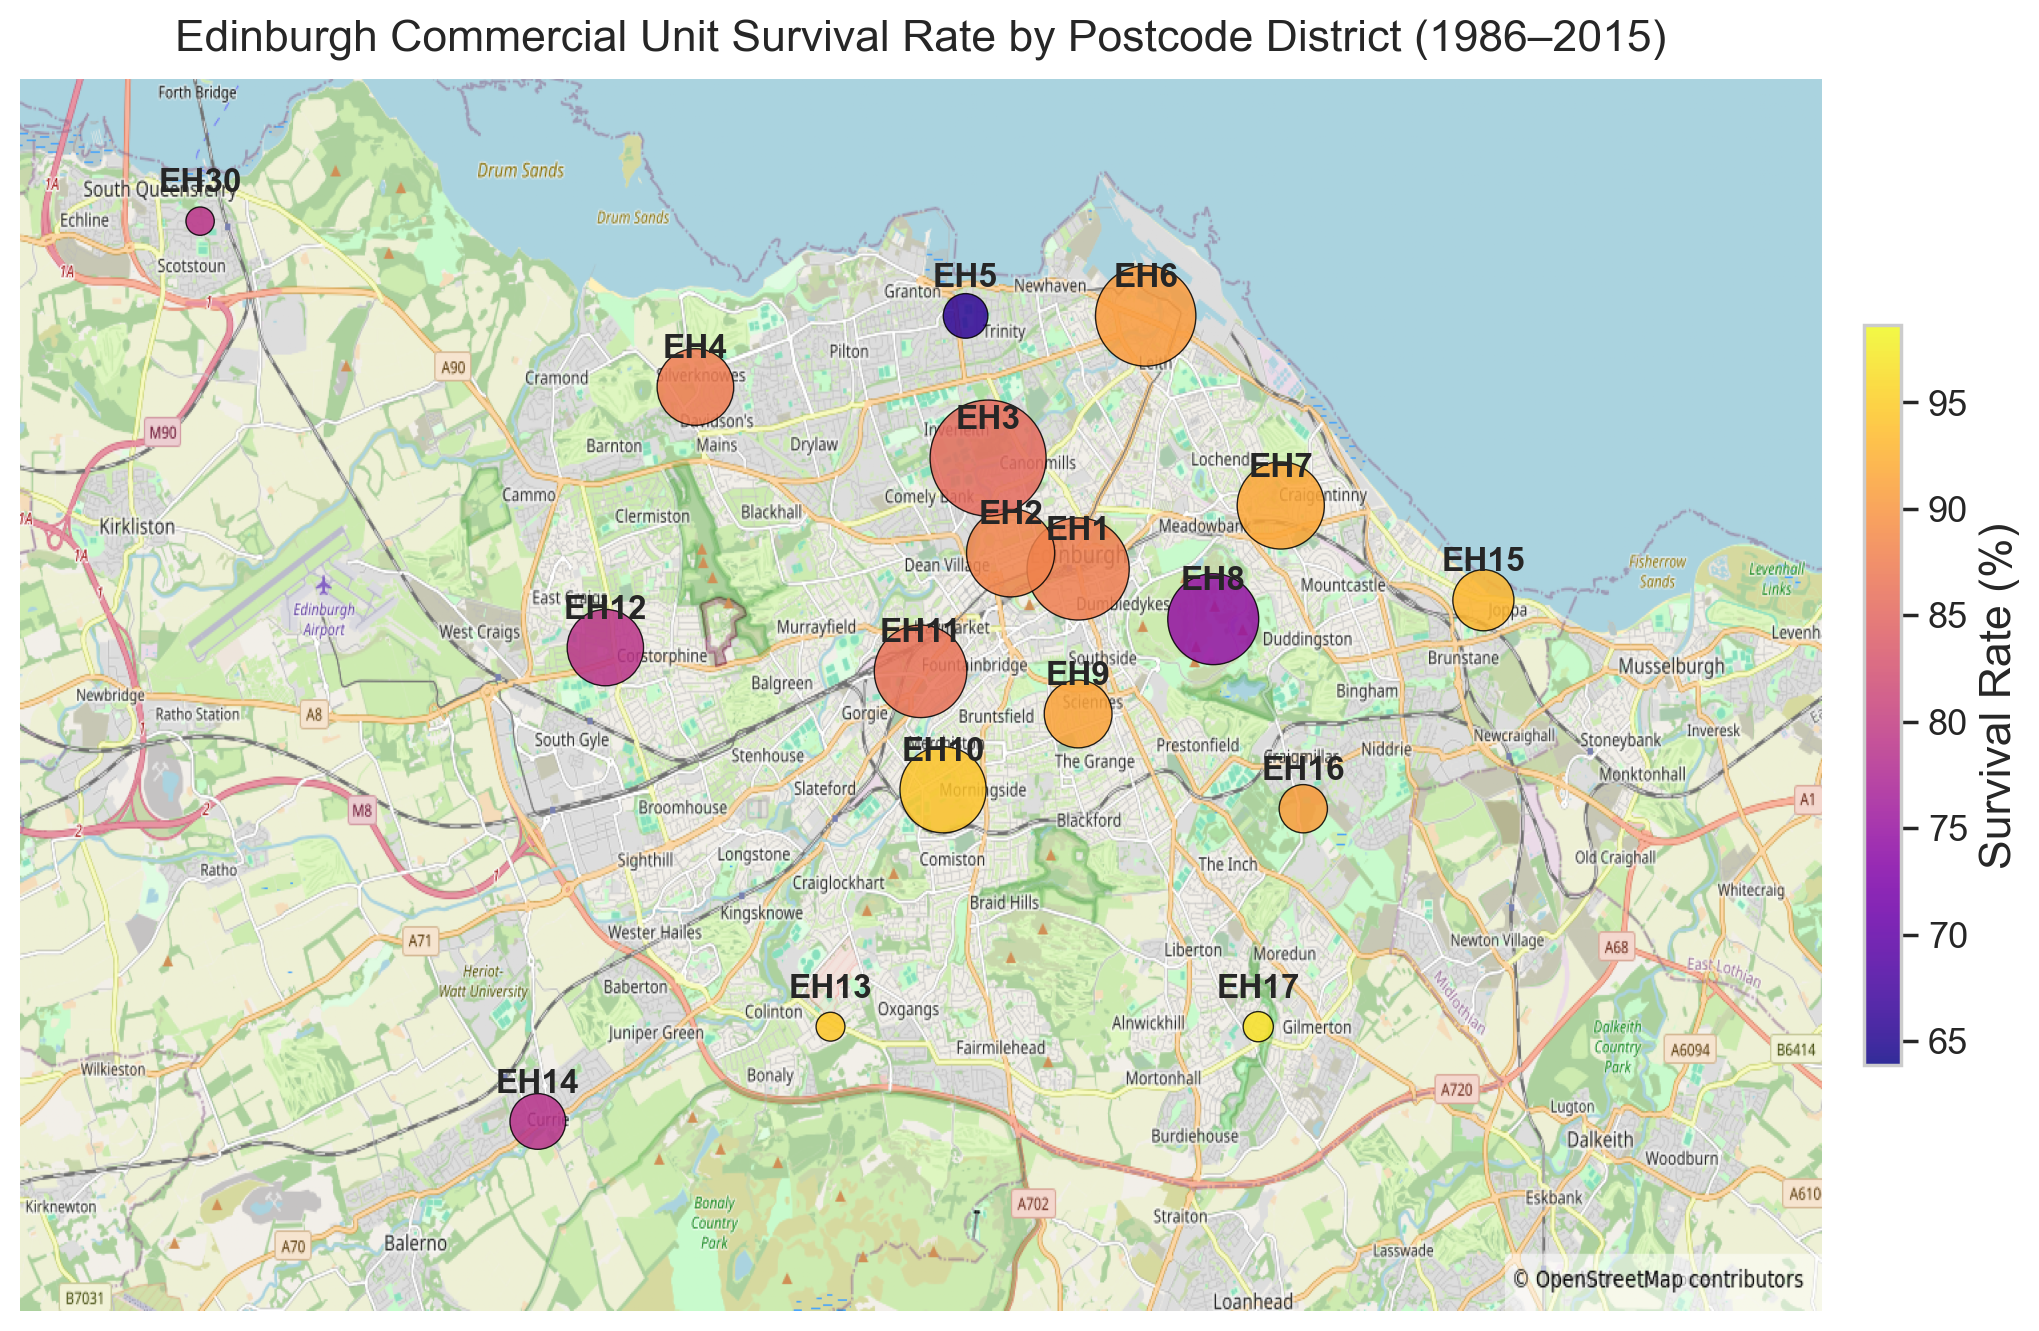

In [36]:
postcode_coords = {
    'EH1':  (55.9533, -3.2050),
    'EH2':  (55.9550, -3.2200),
    'EH3':  (55.9650, -3.2250),
    'EH4':  (55.9725, -3.2900),
    'EH5':  (55.9800, -3.2300),
    'EH6':  (55.9800, -3.1900),
    'EH7':  (55.9600, -3.1600),
    'EH8':  (55.9480, -3.1750),
    'EH9':  (55.9380, -3.2050),
    'EH10': (55.9300, -3.2350),
    'EH11': (55.9425, -3.2400),
    'EH12': (55.9450, -3.3100),
    'EH13': (55.9050, -3.2600),
    'EH14': (55.8950, -3.3250),
    'EH15': (55.9500, -3.1150),
    'EH16': (55.9280, -3.1550),
    'EH17': (55.9050, -3.1650),
    'EH30': (55.9900, -3.4000),
}

# Geographic extent of the PNG map [lon_min, lon_max, lat_min, lat_max]
map_extent = [-3.44, -3.04, 55.875, 56.005]

region_stats = (
    df_analysis.query("Region in @valid_regions")
    .groupby('Region')['Survived']
    .agg(['mean', 'count'])
)

rates = region_stats['mean'] * 100
sizes = region_stats['count'] * 2.0

lons = [postcode_coords[r][1] for r in region_stats.index]
lats = [postcode_coords[r][0] for r in region_stats.index]

norm = mcolors.Normalize(vmin=rates.min() - 2, vmax=rates.max() + 2)
cmap = cm.plasma

fig, ax = plt.subplots(figsize=(14, 8))

# Load and display the PNG as background
bg_img = mpimg.imread('edinburgh_map.png')
ax.imshow(bg_img, extent=map_extent, aspect='auto', zorder=0)

sc = ax.scatter(lons, lats,
                c=rates, cmap=cmap, norm=norm,
                s=sizes,
                edgecolors='black', linewidths=0.5,
                alpha=0.85, zorder=3)

for region, lon, lat in zip(region_stats.index, lons, lats):
    ax.annotate(region,
                xy=(lon, lat),
                fontsize=12, fontweight='bold',
                ha='center', va='bottom',
                xytext=(0, 8), textcoords='offset points')

cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label('Survival Rate (%)', fontsize=16)
cbar.ax.tick_params(labelsize=13)
ax.set_axis_off()
ax.set_title(
    'Edinburgh Commercial Unit Survival Rate'
    ' by Postcode District (1986–2015)', fontsize=16, pad=10
)
fig.savefig('survival_by_region.png', dpi=200, bbox_inches='tight')
plt.show()

**Interpretation:** Survival rates span a **30-percentage-point gap** across regions. Suburban districts (e.g., EH17, EH13) consistently outperform inner-city areas, likely because they serve stable local populations with everyday needs. Conversely, areas experiencing major post-industrial regeneration (EH5) or intense tourism and rent pressures (EH8) exhibit the lowest survival rates.

### Chi-Squared Test of Independence — Region

The dot map suggests that survival rates vary meaningfully by region, but visual inspection alone cannot distinguish a true effect from random sampling noise. To formally test this, we perform a **chi-squared test of independence**. This tests the null hypothesis that survival outcome and postal region are completely unrelated.

* **$H_0$ (Null Hypothesis):** Unit survival is independent of its postal region.
* **$H_1$ (Alternative Hypothesis):** There is a statistically significant relationship between postal region and unit survival.

Rejecting the null hypothesis at the 5% significance level provides formal statistical evidence that `Region` is a meaningful predictor, serving as a robust justification for including it as a feature in our upcoming logistic regression model.

In [37]:
# Build a contingency table: rows = Region, columns = Survived (0 or 1)
contingency = pd.crosstab(
    df_analysis.query("Region in @valid_regions")['Region'],
    df_analysis.query("Region in @valid_regions")['Survived']
)

chi2_stat, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-squared statistic : {chi2_stat:.2f}")
print(f"Degrees of freedom    : {dof}")
print(f"p-value               : {p:.2e}")

Chi-squared statistic : 217.03
Degrees of freedom    : 17
p-value               : 1.05e-36


**Interpretation:** The test yields $\chi^2 = 217.03$ with 17 degrees of freedom (and $p = 1.05 \times 10^{-36}$), leading us to decisively reject the null hypothesis. This confirms that survival outcome and postal region are **not independent**. The geographic differences observed in the chart are statistically significant and not merely an artifact of sampling variability, formally justifying the inclusion of Region as a predictor in our logistic regression model.

## Survival Rate by Initial Commercial Classification (1986–2015)

Next, we examine our second key predictor: a unit's initial 1986 commercial classification (Class). Under Scottish planning regulations, this variable categorises a unit's core commercial function, such as Class 1 (Shops), Class 3 (Food and Drink), or Sui Generis (unique/other units).

Because different commercial sectors possess varying degrees of resilience to long-term economic shifts, exploring this variable allows us to identify which types of businesses were most likely to survive the 29-year study period, and which were most vulnerable.

In [38]:
class_summary = (
    df_analysis
    .groupby('Class_1986')['Survived']
    .agg(['mean', 'count'])
    .sort_values(by='mean', ascending=False)
)

class_summary

,mean,count
Class_1986,,
CLASS 3,0.906907,333
CLASS 1,0.870502,4363
CLASS 2,0.861301,584
CLASS 4,0.858195,543
SUI GENERIS,0.835113,843
CLASS 11,0.804348,46


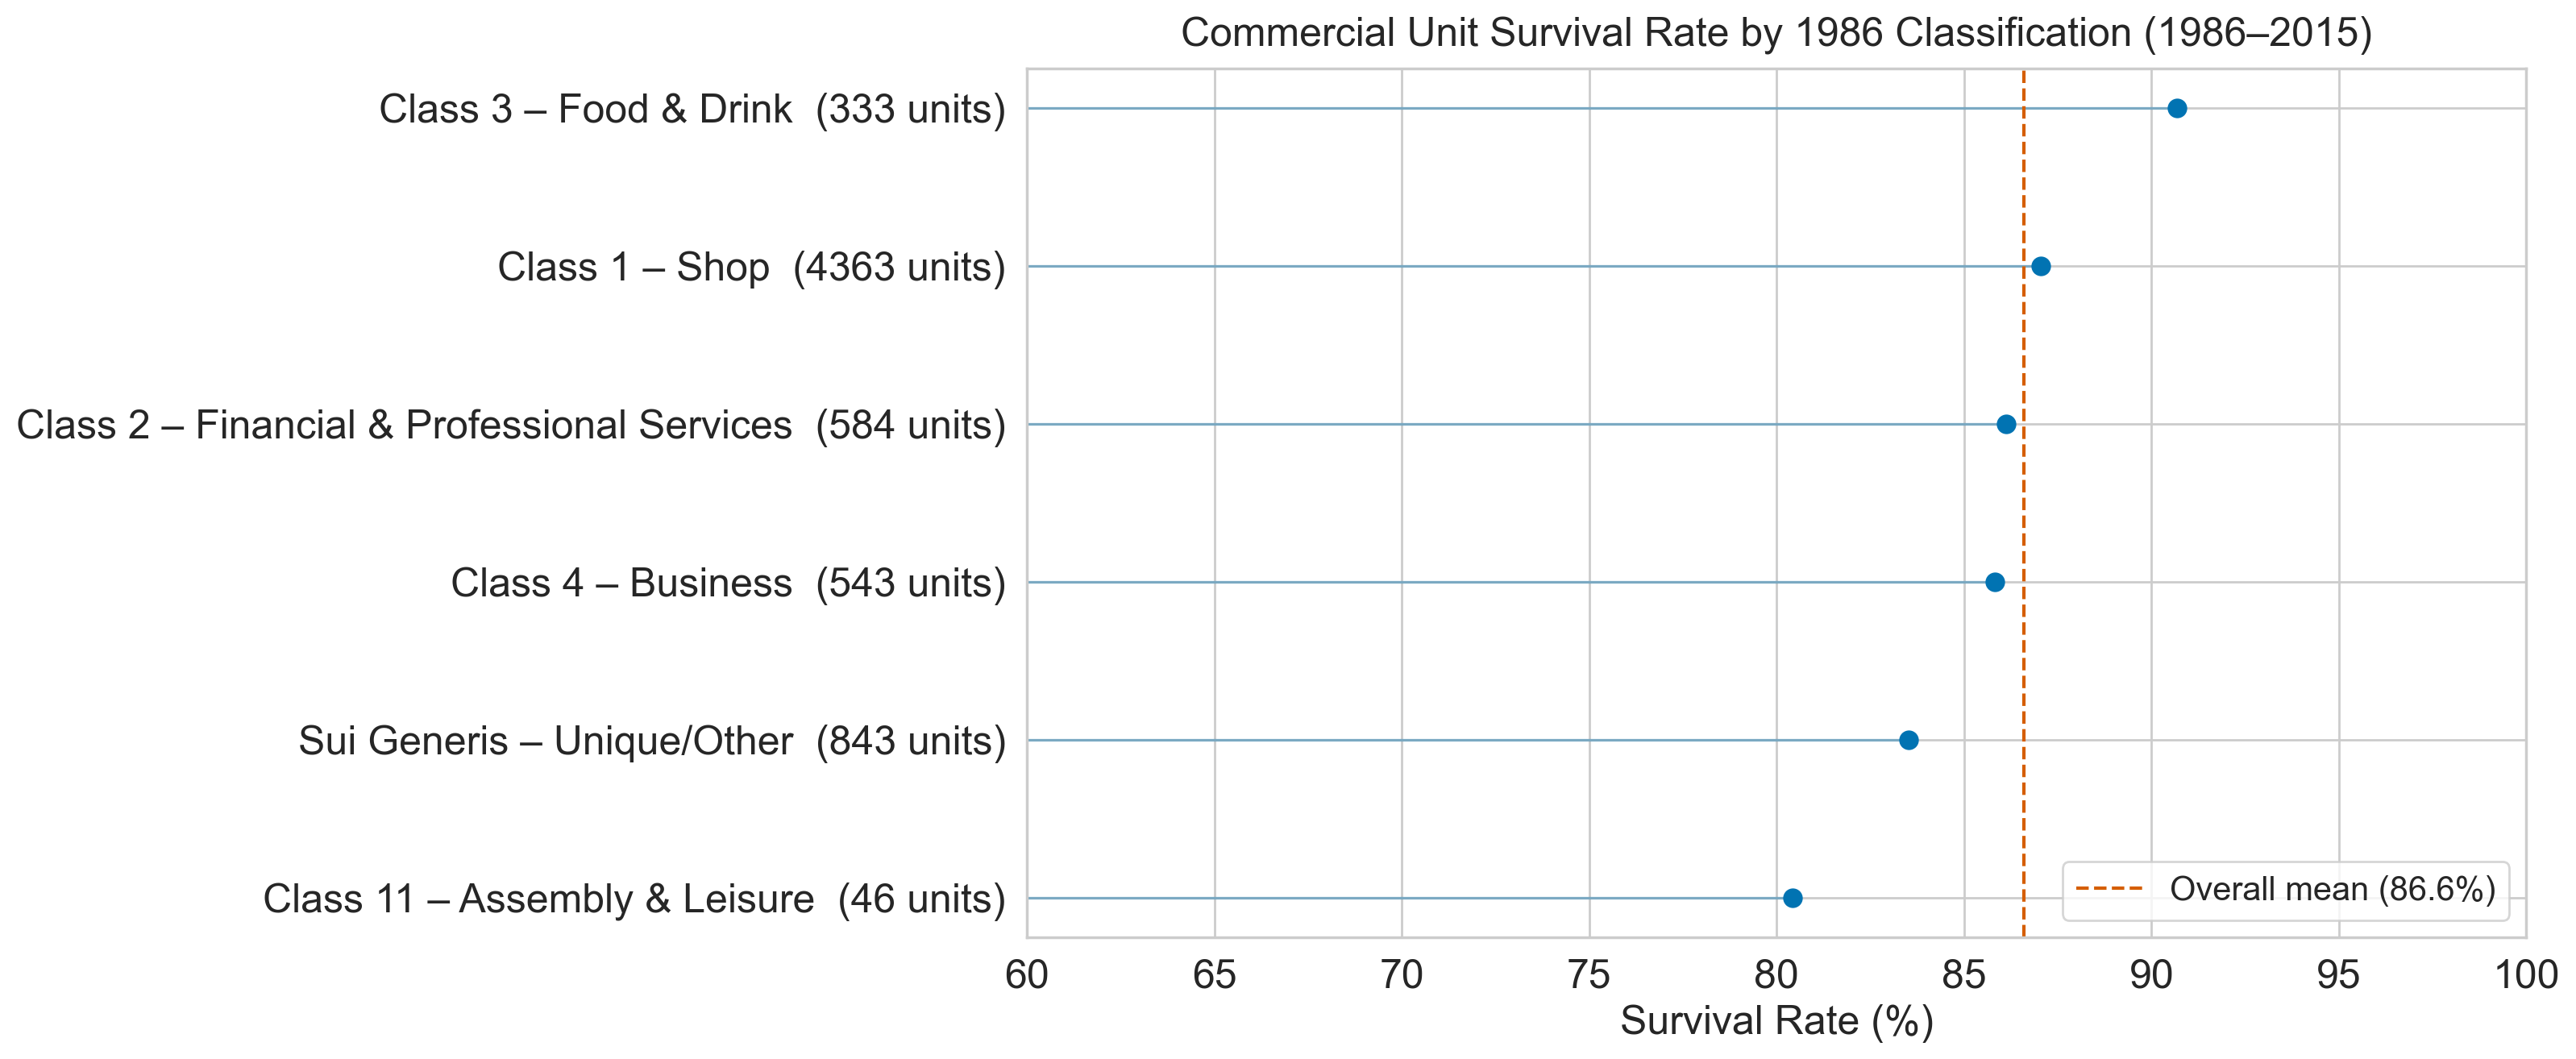

In [39]:
class_label_map = {
    'CLASS 1':      'Class 1 – Shop',
    'CLASS 2':      'Class 2 – Financial & Professional Services',
    'CLASS 3':      'Class 3 – Food & Drink',
    'CLASS 4':      'Class 4 – Business',
    'CLASS 11':     'Class 11 – Assembly & Leisure',
    'SUI GENERIS':  'Sui Generis – Unique/Other',
}

class_stats = (
    df_analysis
    .groupby('Class_1986')['Survived']
    .agg(['mean', 'count'])
    .sort_values('mean')
)

cb = sns.color_palette("colorblind")
fig, ax = plt.subplots(figsize=(12, 7))

y_pos = range(len(class_stats))
labels = [f"{class_label_map.get(c, c)}  ({int(n)} units)"
          for c, n in zip(class_stats.index, class_stats['count'])]
rates = class_stats['mean'] * 100

ax.scatter(rates, y_pos, color=cb[0], s=60, zorder=3)
ax.hlines(y_pos, xmin=0, xmax=rates, color=cb[0], linewidth=1.2, alpha=0.4)

ax.axvline(x=86.6, color=cb[3], linestyle='--', linewidth=1.5, 
           label='Overall mean (86.6%)')

ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=18)
ax.set_xlabel('Survival Rate (%)', fontsize=18)
ax.set_title('Commercial Unit Survival Rate by 1986 Classification (1986–2015)',
            fontsize=18, pad=10)
ax.legend(loc='lower right', fontsize=15)
ax.tick_params(axis='x', labelsize=18)
ax.set_xlim(60, 100)
ax.margins(y=0.05)

fig.savefig('survival_by_class.png', dpi=200, bbox_inches='tight')
plt.show()

**Interpretation:** Survival rates across commercial classes span a much narrower **10-percentage-point gap**. Essential services like Food & Drink (90.7%) and Shops (87.0%) prove highly resilient, whereas discretionary sectors like Assembly & Leisure (80.4%) are more vulnerable. Crucially, comparing this modest 10-point spread to the dramatic 30-point regional gap provides our first hint that where a business locates matters more than what it sells. A hypothesis we will formally test via the Likelihood Ratio Test.


## Chi-Squared Test — Commercial Classification

We apply the same chi-squared test of independence to `Class_1986` to determine whether the observed variation in survival across use-classes is statistically significant or could have arisen by chance.

In [40]:
# Contingency table: rows = Class_1986, columns = Survived (0 or 1)
contingency_class = pd.crosstab(df_analysis['Class_1986'], df_analysis['Survived'])

chi2_stat, p_class, dof_class, expected_class = chi2_contingency(contingency_class)
print(f"Chi-squared statistic : {chi2_stat:.2f}")
print(f"Degrees of freedom    : {dof_class}")
print(f"p-value               : {p_class:.2e}")

Chi-squared statistic : 14.35
Degrees of freedom    : 5
p-value               : 1.35e-02


**Interpretation:** The test yields $\chi^2 = 14.35$ with 5 degrees of freedom (and $p = 0.0135$), confirming that survival and commercial classification are **not independent**. Both Region and Class are now formally validated as significant predictors, justifying their joint inclusion in the logistic regression model.

<span style="display: none">\newpage</span>

# Data Communication and Analysis

# Logistic Regression

## Why Logistic Regression?

Our response variable is binary (survived vs. did not survive), making logistic regression the natural modelling choice. It models the **log-odds** of survival as a linear combination of predictors, ensuring predicted probabilities remain in [0, 1]:

$$\log\!\left(\frac{p}{1-p}\right) = \beta_0 + \beta_1 x_1 + \cdots + \beta_k x_k$$

We use two complementary implementations: **`statsmodels.Logit`** for statistical inference (coefficients, p-values, confidence intervals) and **`sklearn.LogisticRegression`** with `class_weight='balanced'` for fairer prediction that does not default to the 86.6% majority class. We fit both an **additive model** (Region + Class) and an **interaction model** (Region × Class) to test whether the effect of commercial classification depends on location.

## Feature Preparation: One-Hot Encoding and Interaction Terms

Both predictors are categorical, so we convert them to binary dummy variables via one-hot encoding with `drop_first=True` to avoid the **dummy-variable trap**. Interaction terms (pairwise products of every Region dummy with every Class dummy) are also constructed to test whether certain business types fare differently in specific locations.

In [41]:
# One-hot encode categoricals
X = pd.get_dummies(df_analysis[['Region', 'Class_1986']], drop_first=True, dtype=int)
y = df_analysis['Survived']

# Build interaction feature matrix (Region × Class) 
region_cols_feat = [c for c in X.columns if c.startswith('Region_')]
class_cols_feat  = [c for c in X.columns if c.startswith('Class_1986_')]

interaction_parts = []
for rc in region_cols_feat:
    for cc in class_cols_feat:
        interaction_parts.append(
            (X[rc] * X[cc]).rename(f'{rc}:{cc}')
        )
X_interact = pd.concat([X] + interaction_parts, axis=1)

print(f"Additive features:   {X.shape[1]} columns")
print(f"Interaction features: {X_interact.shape[1]} columns  "
      f"(+{X_interact.shape[1] - X.shape[1]} interaction terms)")

Additive features:   22 columns
Interaction features: 107 columns  (+85 interaction terms)


## Train/Test Split and Statsmodels Fit

Before fitting our models, we partition the dataset into an 80% training set and a 20% hold-out test set. Because our target variable is heavily skewed towards survival, we use a stratified split (`stratify=y`). This critical step ensures that both the training and testing sets preserve the exact 86.6% / 13.4% class proportions found in our full dataset, preventing the minority class from being underrepresented during training.

Using the training data, we then fit two logistic regression models using `statsmodels.Logit`. We choose this specific library for its comprehensive statistical output, which provides the p-values and confidence intervals required for rigorous inference:

**The Additive Model:** Captures the independent main effects of Region and Class on unit survival.

**The Interaction Model:** Incorporates our expanded feature matrix to test whether these two predictors interact, specifically, whether the survival probability of a certain commercial class fundamentally changes depending on its geographic location.

In [42]:
X_train_int, X_test_int, y_train, y_test = train_test_split(
    X_interact, y, test_size=0.2, random_state=42, stratify=y
)

additive_cols = X.columns.tolist()
X_train = X_train_int[additive_cols]
X_test  = X_test_int[additive_cols]

X_train_sm = sm.add_constant(X_train)
X_test_sm  = sm.add_constant(X_test)
sm_result  = sm.Logit(y_train, X_train_sm).fit()

X_train_int_sm = sm.add_constant(X_train_int)
X_test_int_sm  = sm.add_constant(X_test_int)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    sm_interact = (sm.Logit(y_train, X_train_int_sm)
                   .fit(method='bfgs', disp=0, maxiter=500))

Optimization terminated successfully.
         Current function value: 0.379660
         Iterations 7


In [43]:
sm_result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:               Survived   No. Observations:                 5369
Model:                          Logit   Df Residuals:                     5346
Method:                           MLE   Df Model:                           22
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                 0.03837
Time:                        11:11:17   Log-Likelihood:                -2038.4
converged:                       True   LL-Null:                       -2119.7
Covariance Type:            nonrobust   LLR p-value:                 1.900e-23
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                      2.0190      0.135     14.962      0.000       1.755       2.284
Region_EH10                0.6813      0.246      2.775      0.006       0.200       1.163
Region_EH11               -0.2194      0.189     -1.164      0.245      -0.589       0.150
Region_EH12               -0.4572      0.201     -2.275      0.023      -0.851      -0.063
Region_EH13                0.5415      0.615      0.880      0.379      -0.664       1.747
Region_EH14               -0.6616      0.232     -2.853      0.004      -1.116      -0.207
Region_EH15                0.4007      0.293      1.369      0.171      -0.173       0.975
Region_EH16                0.2636      0.332      0.795      0.427      -0.386       0.913
Region_EH17                1.1058      0.736      1.502      0.133      -0.337       2.548
Region_EH2                 0.0031      0.203      0.015      0.988      -0.394       0.400
Region_EH3                -0.2058      0.169     -1.215      0.224      -0.538       0.126
Region_EH30               -0.9915      0.394     -2.519      0.012      -1.763      -0.220
Region_EH4                -0.1280      0.215     -0.594      0.552      -0.550       0.294
Region_EH5                -1.3236      0.251     -5.280      0.000      -1.815      -0.832
Region_EH6                 0.2667      0.196      1.359      0.174      -0.118       0.651
Region_EH7                 0.5794      0.236      2.452      0.014       0.116       1.043
Region_EH8                -0.9270      0.173     -5.369      0.000      -1.265      -0.589
Region_EH9                 0.3482      0.264      1.318      0.187      -0.170       0.866
Class_1986_CLASS 11       -0.5714      0.394     -1.451      0.147      -1.343       0.200
Class_1986_CLASS 2        -0.1079      0.146     -0.741      0.459      -0.393       0.178
Class_1986_CLASS 3         0.3707      0.219      1.694      0.090      -0.058       0.800
Class_1986_CLASS 4        -0.0172      0.154     -0.112      0.911      -0.318       0.284
Class_1986_SUI GENERIS    -0.2820      0.118     -2.385      0.017      -0.514      -0.050
==========================================================================================
"""

## Interpreting the Additive Model Summary

The statsmodels output provides a wealth of information about our model's performance and the impact of individual features. We can break this down into three key areas:

Overall Model Fit: The summary reports a McFadden's pseudo $R^2$ of $0.038$. While the overall model is highly statistically significant (LLR p-value is effectively zero), this modest $R^2$ value confirms that Region and Class alone explain only a limited share of the variation in commercial survival. This aligns with our expectations: important unmeasured variables such as rent, proximity to transport, area-level deprivation (e.g. the Scottish Index of Multiple Deprivation), and individual management decisions likely play substantial roles.

Coefficient Interpretation: Each coefficient (coef) represents the change in the log-odds of survival for that specific category relative to the dropped reference baseline. To make these values more intuitive, they can be exponentiated to yield the odds ratio.

Statistical Significance: We look at the $P>|z|$ column and the 95% confidence intervals ([0.025, 0.975]). Coefficients with a p-value $< 0.05$ and confidence intervals that completely exclude zero are deemed statistically significant predictors of long-term survival.

## Odds Ratio Table

While log-odds coefficients are useful for model interpretation, **odds ratios** are more intuitive for decision-makers. An OR of 2.0 means the odds of survival are twice as high for that category relative to the reference; an OR of 0.5 means the odds are halved. We exponentiate each coefficient and its 95% confidence interval, sorting by OR to highlight the strongest predictors.

In [44]:
# Clip coefficients to avoid overflow when exponentiating very large values
clipped_params = sm_result.params.clip(-20, 20)
clipped_ci     = sm_result.conf_int().clip(-20, 20)

odds_ratio_df = pd.DataFrame({
    'Odds Ratio': np.exp(clipped_params),
    'OR Lower 95%': np.exp(clipped_ci[0]),
    'OR Upper 95%': np.exp(clipped_ci[1]),
    'p-value': sm_result.pvalues,
}).drop('const')

# Flag statistical significance at the 5% level
odds_ratio_df['Significant'] = (
    odds_ratio_df['p-value']
    .lt(0.05)
    .map({True: 'Yes', False: 'No'})
)

odds_ratio_df.index = (
    odds_ratio_df.index
    .str.replace('Region_', 'Region: ', regex=False)
    .str.replace('Class_1986_', 'Class: ', regex=False)
)

odds_ratio_df = odds_ratio_df.sort_values('Odds Ratio', ascending=False)

odds_ratio_display = (odds_ratio_df
                      .round({'Odds Ratio': 3, 'OR Lower 95%': 3,
                               'OR Upper 95%': 3}).copy())

odds_ratio_display['p-value'] = odds_ratio_df['p-value'].map('{:.4f}'.format)
display(odds_ratio_display)

,Odds Ratio,OR Lower 95%,OR Upper 95%,p-value,Significant
Region: EH17,3.022,0.714,12.788,0.1330,No
Region: EH10,1.977,1.222,3.198,0.0055,Yes
Region: EH7,1.785,1.123,2.836,0.0142,Yes
Region: EH13,1.719,0.515,5.737,0.3786,No
Region: EH15,1.493,0.841,2.650,0.1711,No
Class: CLASS 3,1.449,0.943,2.225,0.0903,No
Region: EH9,1.417,0.844,2.377,0.1875,No
Region: EH6,1.306,0.889,1.918,0.1741,No
Region: EH16,1.302,0.680,2.493,0.4265,No
Region: EH2,1.003,0.674,1.492,0.9879,No


### Interpretation: Odds Ratios

The Odds Ratio (OR) translates the model’s coefficients into multiplicative effects on survival. An **OR > 1.0** indicates increased odds of survival relative to the baseline (**EH1** for Region and **Class 1** for Class), while an **OR < 1.0** indicates decreased odds.

* **Top Survival Predictors:** **EH10** (OR $= 1.977$) and **EH7** (OR $= 1.785$) are the strongest significant positive drivers. Units in EH10 are nearly twice as likely to survive as those in the baseline district.

* **Highest Risk Locations:** **EH5** (OR $= 0.266$) and **EH8** (OR $= 0.396$) show the most severe reduction in survival odds. A business in EH5 has roughly **73% lower odds** of surviving compared to the baseline. **EH30**, **EH14**, and **EH12** also exhibit significantly lower odds.

* **Commercial Classification:** **Sui Generis** units are the only class with a statistically significant effect ($p = 0.0171$), showing a **25% reduction** in survival odds (OR $= 0.754$). While **Class 3** (Food and Drink) trends positive (OR $= 1.449$), but does not meet the 5% significance threshold ($p = 0.0903$).

**Summary:** Geographic location (Region) offers a much wider range of significant multiplicative effects than commercial classification, reinforcing the conclusion that where a business is located is a more potent predictor of longevity than what it sells.

## Balanced Sklearn Pipelines (Additive and Interaction)

The `statsmodels` models are valuable for inference but do not address class imbalance: with an 86.6% baseline survival rate, an unweighted model tends to predict "survived" for nearly every unit. We wrap `LogisticRegression(class_weight='balanced')` in an `sklearn.Pipeline` with `StandardScaler` to up-weight the minority class and guarantee consistent feature scaling across train and test sets.

In [45]:
# Additive pipeline 
pipe = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)
pipe.fit(X_train, y_train)
y_pred      = pipe.predict(X_test)
y_pred_prob = pipe.predict_proba(X_test)[:, 1]

# Interaction pipeline 
pipe_interact = make_pipeline(
    StandardScaler(),
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
)
pipe_interact.fit(X_train_int, y_train)
y_pred_int      = pipe_interact.predict(X_test_int)
y_pred_prob_int = pipe_interact.predict_proba(X_test_int)[:, 1]

## Model Evaluation on the Test Set

We evaluate both the additive and interaction pipelines on the held-out test set. Because `class_weight='balanced'` penalises errors on the minority class more heavily, we expect improved recall for non-surviving units, even if overall accuracy drops slightly. Comparing the two pipelines reveals whether interaction terms translate into better predictive performance.

In [46]:
print("=" * 60)
print("ADDITIVE MODEL (Region + Class)")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.1%}")
print(classification_report(y_test, y_pred,
                             target_names=['Did Not Survive', 'Survived']))

print("=" * 60)
print("INTERACTION MODEL (Region × Class)")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, y_pred_int):.1%}")
print(classification_report(y_test, y_pred_int,
                             target_names=['Did Not Survive', 'Survived']))

ADDITIVE MODEL (Region + Class)
Accuracy: 59.2%
                 precision    recall  f1-score   support

Did Not Survive       0.19      0.62      0.29       180
       Survived       0.91      0.59      0.71      1163

       accuracy                           0.59      1343
      macro avg       0.55      0.60      0.50      1343
   weighted avg       0.81      0.59      0.66      1343

INTERACTION MODEL (Region × Class)
Accuracy: 61.6%
                 precision    recall  f1-score   support

Did Not Survive       0.20      0.61      0.30       180
       Survived       0.91      0.62      0.74      1163

       accuracy                           0.62      1343
      macro avg       0.55      0.61      0.52      1343
   weighted avg       0.82      0.62      0.68      1343



## Understanding the Classification Report

To evaluate the model's effectiveness, we examine precision (the proportion of predicted failures that actually failed), recall (the proportion of actual failures that the model detected), and the F1-score (their harmonic mean).

Given the significant class imbalance in our test set, where only 180 out of 1,343 units did not survive overall accuracy is a misleading metric. A naive model that simply predicted "Survived" for every unit would achieve 86.6% accuracy but have 0% recall for the units we are most interested in identifying.

By using balanced class weighting, the additive model achieved a recall of 0.62 for the "Did Not Survive" class. This means the model successfully identified 62% of all units that actually failed. While this trades off overall accuracy (dropping it to 59%) and results in lower precision (0.19), it is the correct strategy for this research. In commercial survival analysis, it is far more valuable to flag a high-risk unit (even if it eventually survives) than to miss it entirely.

## Coefficient Plot

This forest plot displays each estimated log-odds coefficient with its 95% confidence interval, enabling rapid visual comparison of all predictors. Coefficients whose intervals exclude the dashed zero line are statistically significant at the 5% level. We exclude the intercept from the plot since its scale differs and it does not correspond to a specific region or use-class.

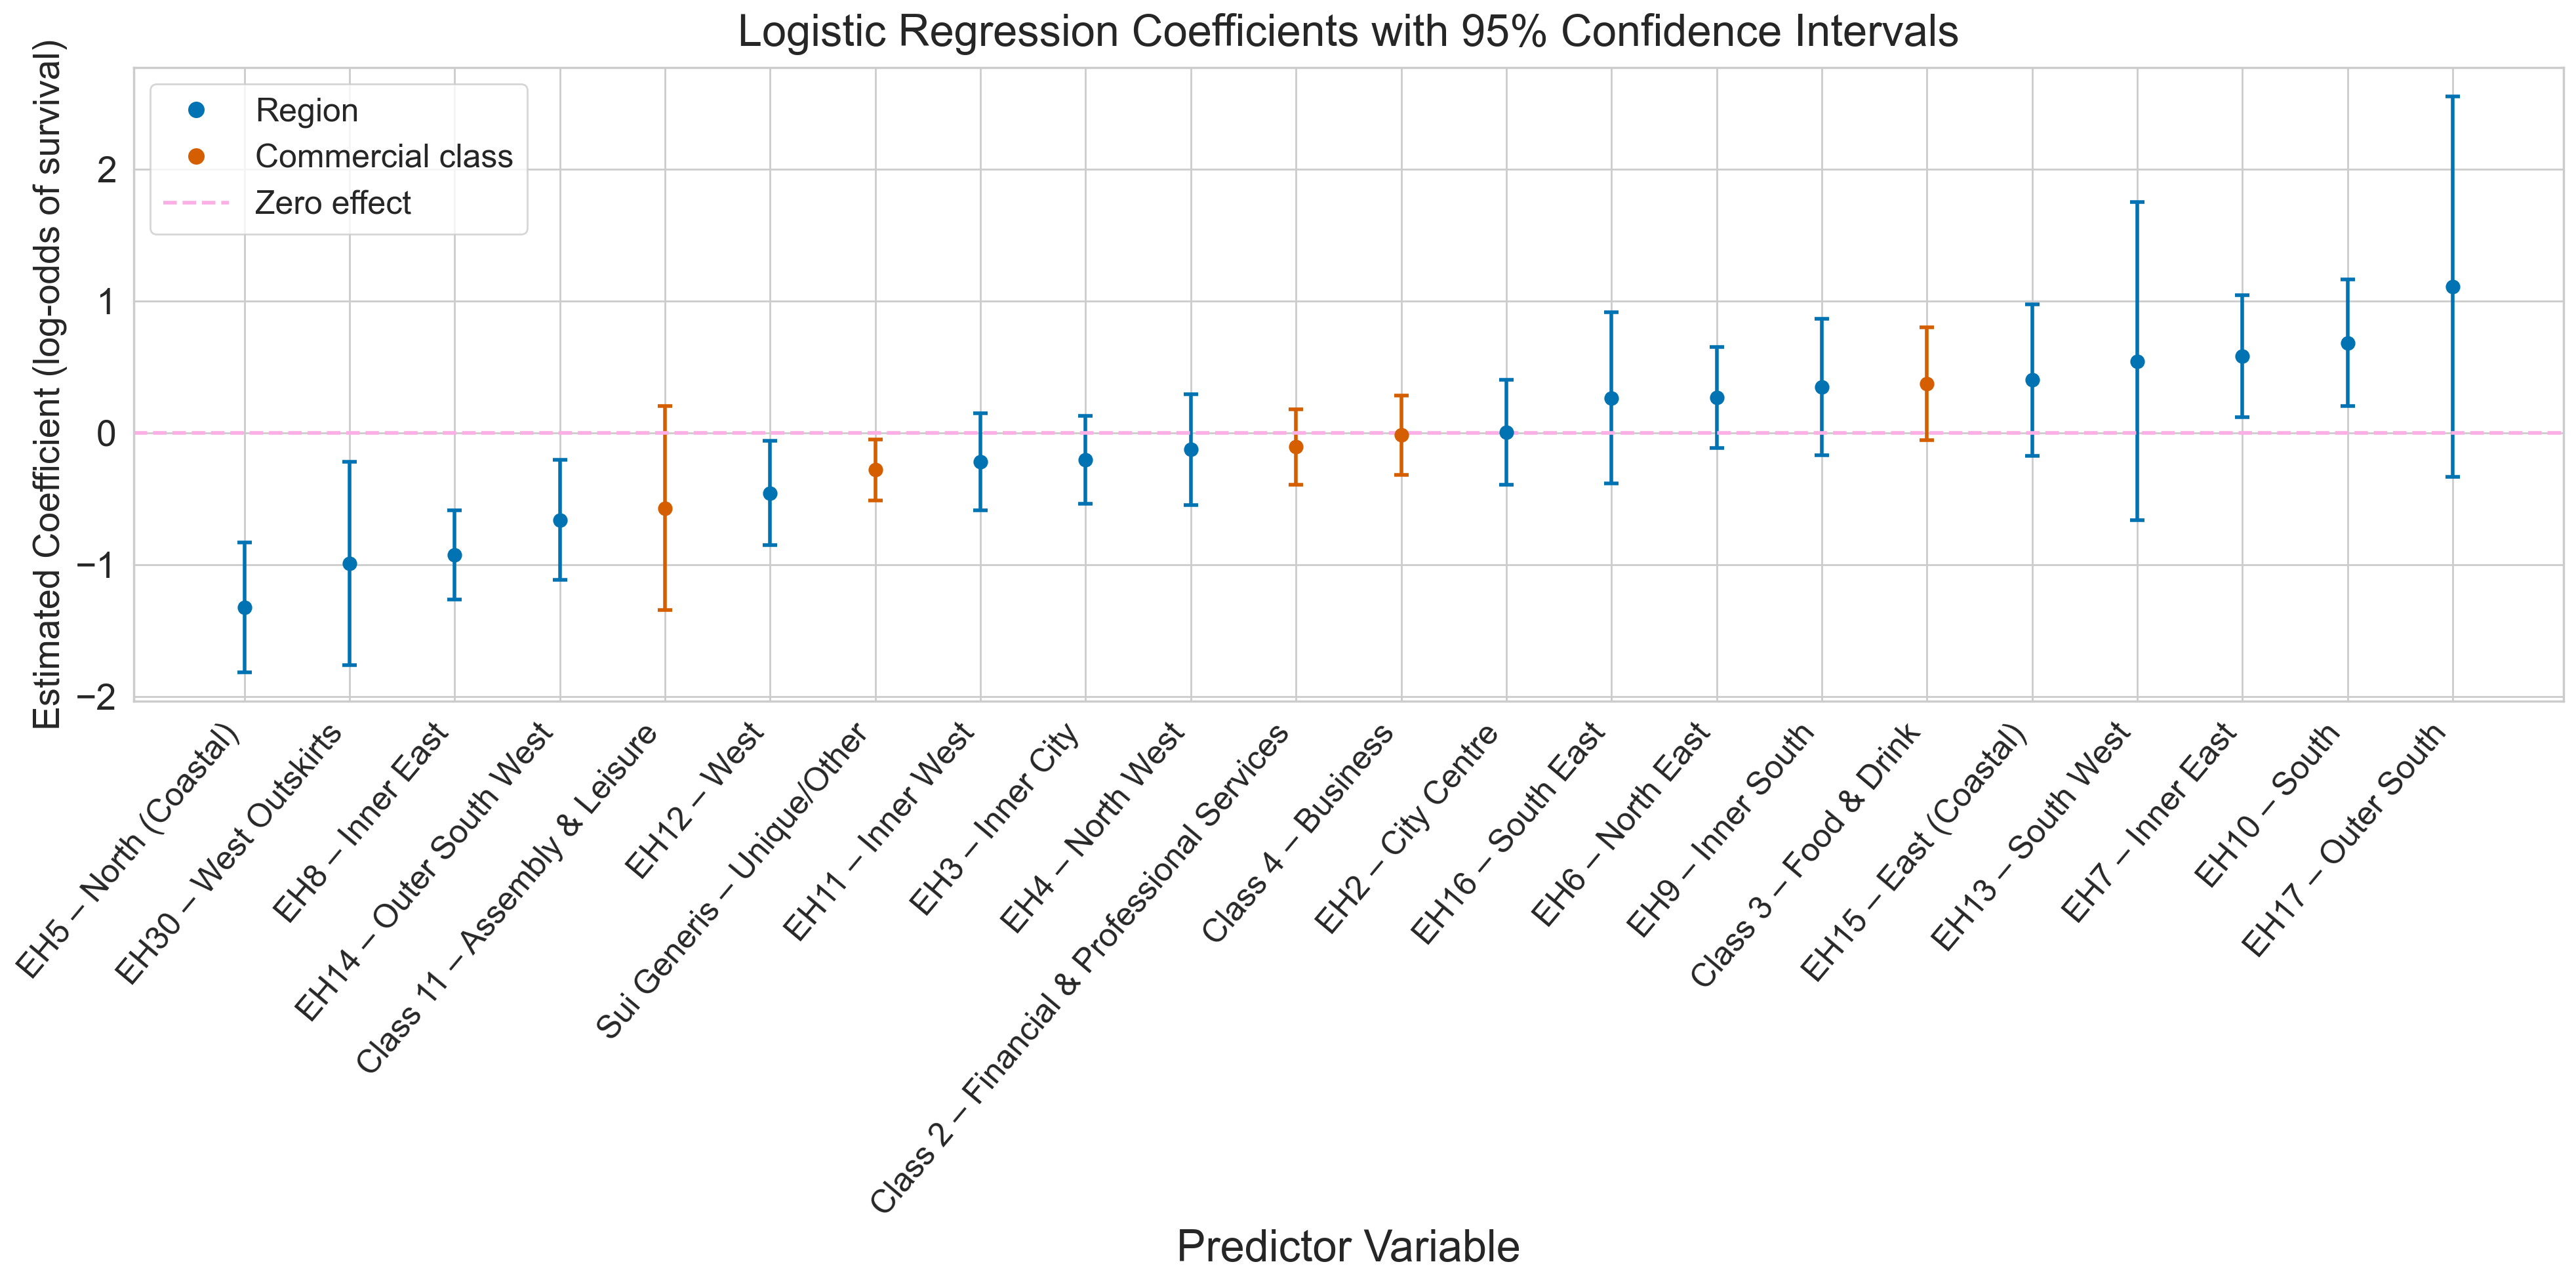

In [47]:
label_map = {
    'Region_EH1':  'EH1 – City Centre',
    'Region_EH2':  'EH2 – City Centre',
    'Region_EH3':  'EH3 – Inner City',
    'Region_EH4':  'EH4 – North West',
    'Region_EH5':  'EH5 – North (Coastal)',
    'Region_EH6':  'EH6 – North East',
    'Region_EH7':  'EH7 – Inner East',
    'Region_EH8':  'EH8 – Inner East',
    'Region_EH9':  'EH9 – Inner South',
    'Region_EH10': 'EH10 – South',
    'Region_EH11': 'EH11 – Inner West',
    'Region_EH12': 'EH12 – West',
    'Region_EH13': 'EH13 – South West',
    'Region_EH14': 'EH14 – Outer South West',
    'Region_EH15': 'EH15 – East (Coastal)',
    'Region_EH16': 'EH16 – South East',
    'Region_EH17': 'EH17 – Outer South',
    'Region_EH30': 'EH30 – West Outskirts',
    
    'Class_1986_CLASS 2':     'Class 2 – Financial & Professional Services',
    'Class_1986_CLASS 3':     'Class 3 – Food & Drink',
    'Class_1986_CLASS 4':     'Class 4 – Business',
    'Class_1986_CLASS 11':    'Class 11 – Assembly & Leisure',
    'Class_1986_SUI GENERIS': 'Sui Generis – Unique/Other',
}

# Process coefficients
coef_df = (
    pd.DataFrame({
        'Coefficient': sm_result.params,
        'Lower CI': sm_result.conf_int()[0],
        'Upper CI': sm_result.conf_int()[1],
    })
    .drop('const')
    .sort_values('Coefficient')
)

# Filter out extreme outliers with massive confidence intervals
ci_width = coef_df['Upper CI'] - coef_df['Lower CI']
coef_df = coef_df[ci_width < 50]

coef_df.index = coef_df.index.map(lambda x: label_map.get(x, x))

cb = sns.color_palette("colorblind")
colours = [cb[0] if 'EH' in lab else cb[3] for lab in coef_df.index]

coeffs    = coef_df['Coefficient'].values
err_lower = coeffs - coef_df['Lower CI'].values
err_upper = coef_df['Upper CI'].values - coeffs
x_pos     = list(range(len(coef_df)))

# Plotting
fig, ax = plt.subplots(figsize=(20, 10))

for i, (coeff, el, eu, col) in enumerate(
        zip(coeffs, err_lower, err_upper, colours)):
    ax.errorbar(x=i, y=coeff, yerr=[[el], [eu]],
                fmt='o', color=col, ecolor=col,
                elinewidth=2, capsize=4, capthick=2, markersize=7)

ax.axhline(y=0, color=cb[6], linestyle='--', linewidth=2.0)

ax.set_xticks(x_pos)
ax.set_xticklabels(coef_df.index, rotation=50, ha='right', fontsize=18)
ax.set_ylabel('Estimated Coefficient (log-odds of survival)', fontsize=20)
ax.set_xlabel('Predictor Variable', fontsize=24)
ax.set_title('Logistic Regression Coefficients with 95% Confidence Intervals',
             fontsize=24, pad=12)
ax.tick_params(axis='y', labelsize=20)

legend_handles = [
    Line2D([0], [0], marker='o', color=cb[0], linestyle='None',
           markersize=8, label='Region'),
    Line2D([0], [0], marker='o', color=cb[3], linestyle='None',
           markersize=8, label='Commercial class'),
    Line2D([0], [0], color=cb[6], linestyle='--',
           linewidth=2.0, label='Zero effect'),
]
ax.legend(handles=legend_handles, loc='upper left', fontsize=18)

fig.tight_layout()
fig.savefig('coefficient_plot.png', dpi=200, bbox_inches='tight')
plt.show()

**Interpretation:** This figure mainly confirms inferential results already reported above: several Region coefficients are clearly away from zero, while most Class effects are smaller with wider overlap around zero. The key value of the plot is visual, it shows at a glance that Region effects are both stronger and more consistently significant than Class effects.

## Region vs. Commercial Class — Which Matters More?

To answer our core research question, we compare nested logistic regression models using the **Likelihood Ratio Test (LRT)**. Dropping Region from the full additive model should produce a larger LRT statistic than dropping Class if location is the stronger predictor. We also test whether adding Region × Class interaction terms significantly improves fit, which would indicate that the two predictors do not operate independently.

In [48]:

# Identify column groups
region_cols = [c for c in X_train.columns if c.startswith('Region_')]
class_cols  = [c for c in X_train.columns if c.startswith('Class_1986_')]

# Fit restricted models on training data (with statsmodels constant)
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    region_only = sm.Logit(y_train, sm.add_constant
                           (X_train[region_cols])).fit(disp=0, maxiter=500)
    class_only  = sm.Logit(y_train, sm.add_constant
                           (X_train[class_cols])).fit(disp=0, maxiter=500)

full_ll     = sm_result.llf      
reg_ll      = region_only.llf
cls_ll      = class_only.llf
interact_ll = sm_interact.llf      

# LRT: additive vs restricted 
lr_drop_class  = -2 * (reg_ll  - full_ll)  
lr_drop_region = -2 * (cls_ll  - full_ll)  
df_class  = len(class_cols)
df_region = len(region_cols)
p_drop_class  = chi2.sf(lr_drop_class,  df_class)
p_drop_region = chi2.sf(lr_drop_region, df_region)

# LRT: interaction vs additive 
interaction_cols = [c for c in X_train_int.columns if ':' in c]
lr_interaction   = -2 * (full_ll - interact_ll)
df_interaction   = len(interaction_cols)
p_interaction    = chi2.sf(lr_interaction, df_interaction)

# Comparison table
comparison = pd.DataFrame({
    'LRT Statistic': [None, lr_drop_class, lr_drop_region, lr_interaction],
    'LRT p-value': [None, p_drop_class, p_drop_region, p_interaction],
}, index=[
    'Full (Region + Class)',
    'Region-only (drop Class)',
    'Class-only (drop Region)',
    'Interaction (Region × Class)',
])

# Format
comparison_display = comparison.copy()
comparison_display['LRT Statistic'] = comparison_display['LRT Statistic'].apply(
    lambda x: f'{x:.2f}' if pd.notna(x) else '—')
comparison_display['LRT p-value']   = comparison_display['LRT p-value'].apply(
    lambda x: f'{x:.2e}' if pd.notna(x) else '—')

print("Model Comparison — Region vs. Commercial Class vs. Interaction\n")
display(comparison_display)


Model Comparison — Region vs. Commercial Class vs. Interaction



,LRT Statistic,LRT p-value
Full (Region + Class),—,—
Region-only (drop Class),11.61,4.05e-02
Class-only (drop Region),150.82,1.69e-23
Interaction (Region × Class),102.69,9.30e-02


**Interpretation:** The LRT decisively answers our core research question. Dropping Region from the full model produces a far larger LRT statistic (**150.82**, $p = 1.69 \times 10^{-23}$) than dropping Class (**11.61**, $p = 0.0405$), confirming that **geographic location is the substantially stronger predictor** of long-term survival.

Adding Region × Class interaction terms does *not* significantly improve model fit (LRT = 102.69, $p = 0.0930$), indicating the two predictors operate **independently**. An additive model is sufficient: certain regions are harder for *all* business types, and certain classes are more vulnerable *everywhere*.

## ROC Curve and AUC

The ROC curve evaluates model discrimination across all classification thresholds rather than a single arbitrary cutoff, which is especially valuable given our class imbalance. An AUC significantly above 0.5 confirms the model has learned meaningful patterns.

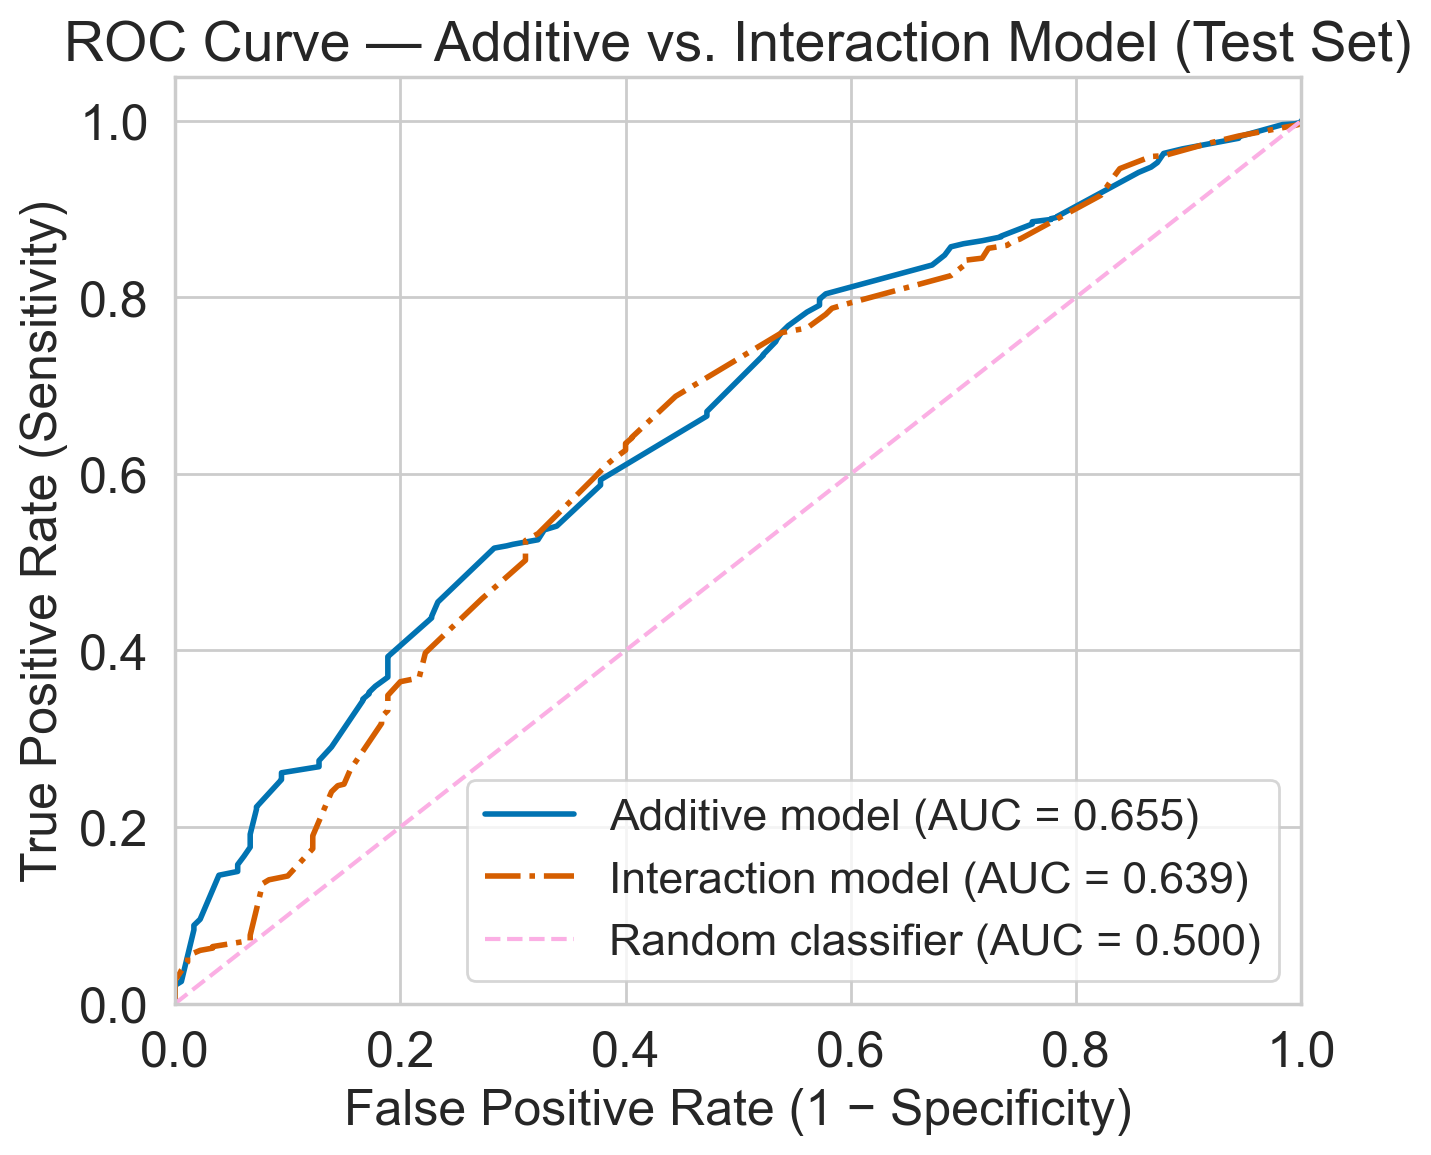

In [49]:
# ROC curves — Additive vs. Interaction
fpr_add, tpr_add, _ = roc_curve(y_test, y_pred_prob)
roc_auc_add = auc(fpr_add, tpr_add)

fpr_int, tpr_int, _ = roc_curve(y_test, y_pred_prob_int)
roc_auc_int = auc(fpr_int, tpr_int)

cb = sns.color_palette("colorblind")
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_add, tpr_add, color=cb[0], lw=2,
        label=f'Additive model (AUC = {roc_auc_add:.3f})')
ax.plot(fpr_int, tpr_int, color=cb[3], lw=2, linestyle='-.',
        label=f'Interaction model (AUC = {roc_auc_int:.3f})')
ax.plot([0, 1], [0, 1], color=cb[6], lw=1.5, linestyle='--',
        label='Random classifier (AUC = 0.500)')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 − Specificity)', fontsize=18)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=18)
ax.set_title('ROC Curve — Additive vs. Interaction Model (Test Set)', fontsize=20)
ax.legend(loc='lower right', fontsize=16)
ax.tick_params(axis='both', labelsize=18)
fig.tight_layout()
fig.savefig('roc_curve.png', bbox_inches='tight')
plt.show()

**Interpretation:** Both models perform above the random-classifier diagonal (AUC > 0.5), confirming they have learned meaningful patterns from Region and Class alone. However, the modest test AUC of **0.655** indicates limited discriminative power. The model correctly ranks a randomly chosen surviving unit above a non-surviving one only about 65.5% of the time. The interaction model shows no meaningful AUC improvement over the additive model, reinforcing the LRT finding that interaction terms are unnecessary.

This modest performance is expected: Region and Class capture broad geographic and sectoral effects, but unmeasured confounders — such as rent levels, proximity to transport, area-level deprivation, and individual management decisions — likely account for much of the remaining variation in survival outcomes.

## I used AI (Gemini) to help with clarity within my writing